##### Training

In [2]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 38.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 KB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 33.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 KB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch-geometric 2.6.1 requires fsspec, which is not installed.


In [3]:
import gensim
from gensim.models import Word2Vec
import multiprocessing

data_dir = r'./1-billion-word-language-modeling-benchmark-r13output/training-monolingual.tokenized.shuffled/*'


In [ ]:
def read_corpus(path):
    import glob
    for file in glob.glob(path):
        with open(file, "r", encoding="utf-8") as f:
            for line in f:
                yield line.strip().split()

sentences = list(read_corpus(data_dir))

In [5]:
print("here")
model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=multiprocessing.cpu_count())
model.save("word2vec_1b_1.model")

here


NameError: name 'Word2Vec' is not defined

##### Testing

In [33]:
from gensim.models import Word2Vec

model = Word2Vec.load("word2vec_1b_streamed.model")
print("Model loaded.")


Model loaded.


In [5]:
words_to_check = ["doctor", "nurse", "engineer", "teacher", "surgeon", "homemaker", "he", "she", "man", "woman"]
for w in words_to_check:
    print(f"{w}: {'YES' if w in model.wv else 'NO'}")


doctor: YES
nurse: YES
engineer: YES
teacher: YES
surgeon: YES
homemaker: YES
he: YES
she: YES
man: YES
woman: YES


In [6]:
import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

male_words = ["man", "he", "male", "him"]
female_words = ["woman", "she", "female", "her"]

occupations = ["doctor", "nurse", "engineer", "teacher", "surgeon", "homemaker"]

for job in occupations:
    if job not in model.wv:
        continue
    job_vec = model.wv[job]

    sim_male = np.mean([cosine_similarity(job_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female = np.mean([cosine_similarity(job_vec, model.wv[f]) for f in female_words if f in model.wv])

    print(f"{job:10s} | male={sim_male:.3f}, female={sim_female:.3f}")


doctor     | male=0.417, female=0.395
nurse      | male=0.361, female=0.421
engineer   | male=0.112, female=0.074
teacher    | male=0.357, female=0.391
surgeon    | male=0.275, female=0.256
homemaker  | male=0.276, female=0.391


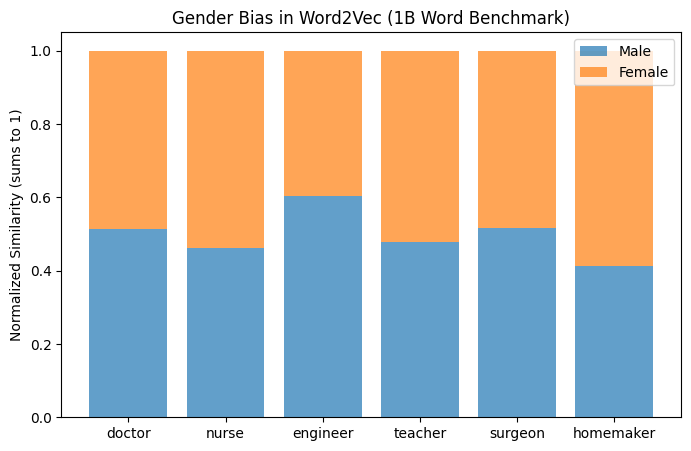

In [4]:
import matplotlib.pyplot as plt

labels, male_scores, female_scores = [], [], []

for job in occupations:
    if job not in model.wv:
        continue
    job_vec = model.wv[job]
    sim_male = np.mean([cosine_similarity(job_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female = np.mean([cosine_similarity(job_vec, model.wv[f]) for f in female_words if f in model.wv])
    total = sim_male + sim_female
    labels.append(job)
    male_scores.append(sim_male / total)
    female_scores.append(sim_female / total)

x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar(x, male_scores, label="Male", alpha=0.7)
plt.bar(x, female_scores, bottom=male_scores, label="Female", alpha=0.7)
plt.xticks(x, labels)
plt.ylabel("Normalized Similarity (sums to 1)")
plt.title("Gender Bias in Word2Vec (1B Word Benchmark)")
plt.legend()
plt.show()


##### De-Biasing

###### Hard Debiasing


In [ ]:
import numpy as np

def normalize(v):
    return v / np.linalg.norm(v)


gender_pairs = [("he", "she"), ("man", "woman"), ("male", "female"), ("him", "her")]
gender_diffs = [normalize(model.wv[m] - model.wv[f]) for m, f in gender_pairs if m in model.wv and f in model.wv]
gender_direction = normalize(np.mean(gender_diffs, axis=0))

neutral_words = ["doctor", "nurse", "engineer", "teacher", "surgeon", "homemaker"]

for word in neutral_words:
    if word in model.wv:
        vec = model.wv[word]
        projection = np.dot(vec, gender_direction) * gender_direction
        model.wv[word] = vec - projection  


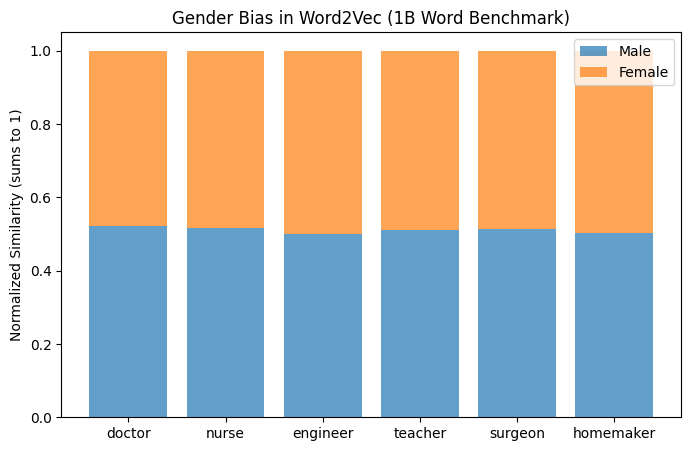

In [6]:
import matplotlib.pyplot as plt

labels, male_scores, female_scores = [], [], []

for job in occupations:
    if job not in model.wv:
        continue
    job_vec = model.wv[job]
    sim_male = np.mean([cosine_similarity(job_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female = np.mean([cosine_similarity(job_vec, model.wv[f]) for f in female_words if f in model.wv])
    total = sim_male + sim_female
    labels.append(job)
    male_scores.append(sim_male / total)
    female_scores.append(sim_female / total)

x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar(x, male_scores, label="Male", alpha=0.7)
plt.bar(x, female_scores, bottom=male_scores, label="Female", alpha=0.7)
plt.xticks(x, labels)
plt.ylabel("Normalized Similarity (sums to 1)")
plt.title("Gender Bias in Word2Vec (1B Word Benchmark)")
plt.legend()
plt.show()


###### Soft Debiasing


In [ ]:
import numpy as np

def normalize(v):
    return v / np.linalg.norm(v)


gender_pairs = [("he", "she"), ("man", "woman"), ("male", "female"), ("him", "her")]
gender_diffs = [normalize(model.wv[m] - model.wv[f]) for m, f in gender_pairs if m in model.wv and f in model.wv]
gender_direction = normalize(np.mean(gender_diffs, axis=0))

neutral_words = ["doctor", "nurse", "engineer", "teacher", "surgeon", "homemaker"]

for word in neutral_words:
    if word in model.wv:
        vec = model.wv[word]
        projection = np.dot(vec, gender_direction) * gender_direction
        model.wv[word] = vec - 0.7*projection  


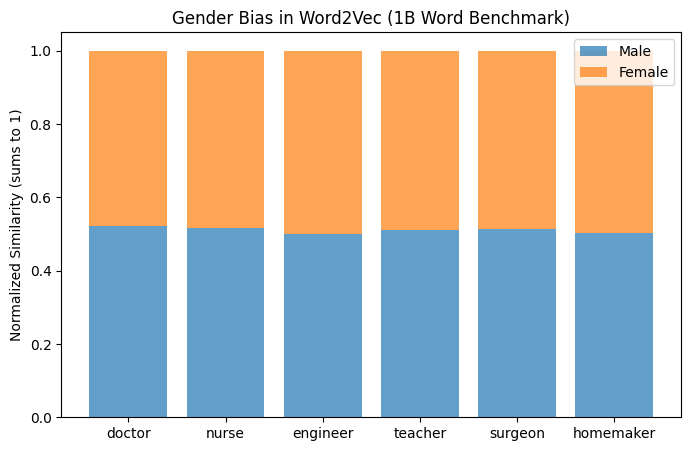

In [8]:
import matplotlib.pyplot as plt

labels, male_scores, female_scores = [], [], []

for job in occupations:
    if job not in model.wv:
        continue
    job_vec = model.wv[job]
    sim_male = np.mean([cosine_similarity(job_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female = np.mean([cosine_similarity(job_vec, model.wv[f]) for f in female_words if f in model.wv])
    total = sim_male + sim_female
    labels.append(job)
    male_scores.append(sim_male / total)
    female_scores.append(sim_female / total)

x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar(x, male_scores, label="Male", alpha=0.7)
plt.bar(x, female_scores, bottom=male_scores, label="Female", alpha=0.7)
plt.xticks(x, labels)
plt.ylabel("Normalized Similarity (sums to 1)")
plt.title("Gender Bias in Word2Vec (1B Word Benchmark)")
plt.legend()
plt.show()


##### Testing

In [2]:
def sentence_embedding(sentence, w2v_model):
    words = [w for w in sentence.lower().split() if w in w2v_model.wv]
    if not words:
        return None
    vectors = [w2v_model.wv[w] for w in words]
    return np.mean(vectors, axis=0)


In [ ]:
def gender_projection(vec, gender_dir):
    return np.dot(vec, gender_dir) / np.linalg.norm(gender_dir)

def gender_contribution_drop(sentence, gender_words, model, gender_dir):
    original = sentence_embedding(sentence, model)
    if original is None:
        return None
    
    pruned = " ".join([w for w in sentence.lower().split() if w not in gender_words])
    pruned_vec = sentence_embedding(pruned, model)
    if pruned_vec is None:
        return None

    proj_orig = gender_projection(original, gender_dir)
    proj_pruned = gender_projection(pruned_vec, gender_dir)
    
    drop = abs(proj_orig - proj_pruned)  
    return drop


In [ ]:
! pip install scikit-learn
from sklearn.decomposition import PCA

gender_pairs = [
    ("he", "she"), ("man", "woman"), ("king", "queen"),
    ("father", "mother"), ("boy", "girl"), ("son", "daughter"),
    ("husband", "wife"), ("brother", "sister")
]

def mean_diff_gender_direction(model, pairs):
    diffs = []
    for m, f in pairs:
        if m in model.wv and f in model.wv:
            diffs.append(model.wv[f] - model.wv[m])  
    direction = np.mean(diffs, axis=0)
    return direction / np.linalg.norm(direction)


gender_direction = mean_diff_gender_direction(model,gender_pairs)

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
def projection_drop(sentence, word_to_remove, model, gender_dir):
    full_vec = sentence_embedding(sentence, model)
    if full_vec is None:
        return None

    pruned = " ".join([w for w in sentence.lower().split() if w != word_to_remove])
    pruned_vec = sentence_embedding(pruned, model)
    if pruned_vec is None:
        return None

    proj_full = np.dot(full_vec, gender_dir)
    proj_pruned = np.dot(pruned_vec, gender_dir)

    drop = abs(proj_full - proj_pruned)
    return drop, proj_full, proj_pruned


In [36]:
drop, p_full, p_pruned = projection_drop("She is a doctor", "she", model, gender_direction)
print("Drop:", drop)
print("With 'she':", p_full)
print("Without 'she':", p_pruned)

drop, p_full, p_pruned = projection_drop("She is a mother", "she", model, gender_direction)
print("Drop:", drop)
print("With 'she':", p_full)
print("Without 'she':", p_pruned)

gendered_sentences = [
    "She is a mother",
    "She is a queen",
    "She is a sister",
    "She is a daughter",
    "She is a wife"
]
for sent in gendered_sentences:
    drop, p_full, p_pruned = projection_drop(sent, "she", model, gender_direction)
    print(f"Sentence: '{sent}'")
    print("  Drop:", drop)
    print("  With 'she':", p_full)
    print("  Without 'she':", p_pruned)

neutral_sentences = [
    "She is a doctor",
    "She is an engineer",
    "She is a teacher",
    "She is a scientist",
    "She is a manager"
]
for sent in neutral_sentences:
    drop, p_full, p_pruned = projection_drop(sent, "she", model, gender_direction)
    print(f"Sentence: '{sent}'")
    print("  Drop:", drop)
    print("  With 'she':", p_full)
    print("  Without 'she':", p_pruned)

Drop: 1.9725065
With 'she': 2.981635
Without 'she': 1.0091286
Drop: 1.469744
With 'she': 4.489924
Without 'she': 3.02018
Sentence: 'She is a mother'
  Drop: 1.469744
  With 'she': 4.489924
  Without 'she': 3.02018
Sentence: 'She is a queen'
  Drop: 1.7941532
  With 'she': 3.5166965
  Without 'she': 1.7225432
Sentence: 'She is a sister'
  Drop: 1.5102816
  With 'she': 4.36831
  Without 'she': 2.8580284
Sentence: 'She is a daughter'
  Drop: 1.368154
  With 'she': 4.7946916
  Without 'she': 3.4265375
Sentence: 'She is a wife'
  Drop: 1.583745
  With 'she': 4.147919
  Without 'she': 2.5641742
Sentence: 'She is a doctor'
  Drop: 1.9725065
  With 'she': 2.981635
  Without 'she': 1.0091286
Sentence: 'She is an engineer'
  Drop: 2.6894133
  With 'she': 0.8309149
  Without 'she': -1.8584983
Sentence: 'She is a teacher'
  Drop: 1.9618266
  With 'she': 3.0136752
  Without 'she': 1.0518486
Sentence: 'She is a scientist'
  Drop: 2.6153252
  With 'she': 1.0531794
  Without 'she': -1.5621458
Sentence

In [34]:
np.dot(gender_direction,sentence_embedding("she is a king", model))

1.0316442

In [18]:
gender_words = {"he", "she", "his", "her"}

s1 = "She is a doctor"
s2 = "She is a mother"
print("Doctor:", gender_contribution_drop("She is a doctor", gender_words, model, gender_direction))
print("Mother:", gender_contribution_drop("She is a mother", gender_words, model, gender_direction))



Doctor: 1.3291054581124266
Mother: 1.5948539912295643


##### Dynamic Learned Neutralization

In [1]:
gender_pairs = [
    ("he", "she"), ("man", "woman"), ("king", "queen"), ("brother", "sister"),
    ("father", "mother"), ("boy", "girl"), ("son", "daughter"), ("husband", "wife")
]


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

def mean_diff_gender_direction(model, pairs):
    diffs = []
    for m, f in pairs:
        if m in model.wv and f in model.wv:
            diffs.append(model.wv[f] - model.wv[m])
    direction = np.mean(diffs, axis=0)
    return direction / np.linalg.norm(direction)

gender_pairs = [
    ("he", "she"), ("man", "woman"), ("king", "queen"),
    ("father", "mother"), ("boy", "girl"), ("son", "daughter"),
    ("husband", "wife"), ("brother", "sister")
]

gender_direction = mean_diff_gender_direction(model, gender_pairs)

def sentence_embedding(sentence, model):
    tokens = [w for w in sentence.lower().split() if w in model.wv]
    if not tokens:
        return None
    return np.mean([model.wv[w] for w in tokens], axis=0)

def projection_drop(sentence, word_to_remove, model, gender_dir):
    full = sentence_embedding(sentence, model)
    if full is None:
        return None, None

    pruned = " ".join([w for w in sentence.lower().split() if w != word_to_remove])
    pruned_vec = sentence_embedding(pruned, model)
    if pruned_vec is None:
        return None, None

    proj_full = np.dot(full, gender_dir)
    proj_pruned = np.dot(pruned_vec, gender_dir)

    drop = abs(proj_full - proj_pruned)
    return full, drop

class DLNDataset(Dataset):
    def __init__(self, sentences, model, gender_dir):
        self.samples = []
        for s in sentences:
            if "she" in s:
                gender_word = "she"
            elif "he" in s:
                gender_word = "he"
            else:
                continue 

            vec, drop = projection_drop(s, gender_word, model, gender_dir)
            if vec is not None:
                self.samples.append((torch.tensor(vec, dtype=torch.float32),
                                     torch.tensor([drop], dtype=torch.float32)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


class DLNGate(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  
        )

    def forward(self, x):
        return self.net(x)
sentences = [
    "She is a doctor", "He is a doctor", "She works as a doctor", "He works as a doctor",
    "She is an engineer", "He is an engineer", "She works as an engineer", "He works as an engineer",
    "She is a teacher", "He is a teacher", "She works as a teacher", "He works as a teacher",
    "She is a scientist", "He is a scientist", "She works as a scientist", "He works as a scientist",
    "She is a lawyer", "He is a lawyer", "She works as a lawyer", "He works as a lawyer",
    "She is a driver", "He is a driver", "She works as a driver", "He works as a driver",
    "She is a manager", "He is a manager", "She works as a manager", "He works as a manager",
    "She is a designer", "He is a designer", "She works as a designer", "He works as a designer",
    "She is a pilot", "He is a pilot", "She works as a pilot", "He works as a pilot",
    "She is a programmer", "He is a programmer", "She works as a programmer", "He works as a programmer",
    "She is a consultant", "He is a consultant", "She works as a consultant", "He works as a consultant",

    "She is a mother", "He is a father",
    "She is a queen", "He is a king",
    "She is a daughter", "He is a son",
    "She is a sister", "He is a brother",
    "She is a wife", "He is a husband",
    "She is an aunt", "He is an uncle",
    "She is a woman", "He is a man",
    "She is pregnant", "He is a widower",
    "She is a bride", "He is a groom",

    "She leads as a scientist", "He leads as a scientist",
    "She excels as a teacher", "He excels as a teacher",
    "She is known as a manager", "He is known as a manager",
    "She performs as a lawyer", "He performs as a lawyer",
    "She is a famous pilot", "He is a famous pilot",
    "She is skilled as an engineer", "He is skilled as an engineer",
    "She excels as a consultant", "He excels as a consultant",
    "She is a brilliant programmer", "He is a brilliant programmer",
    "She serves as a doctor", "He serves as a doctor"
]
dataset = DLNDataset(sentences, model, gender_direction)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

gate = DLNGate(model.vector_size)
optimizer = torch.optim.Adam(gate.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

max_drop = max(drop.item() for _, drop in dataset)

for epoch in range(20):
    total_loss = 0.0
    for x, y in loader:
        y_norm = y / max_drop  
        pred = gate(x)
        loss = loss_fn(pred, y_norm)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")


Epoch 1 | Loss: 1.3880
Epoch 2 | Loss: 1.2120
Epoch 3 | Loss: 1.1478
Epoch 4 | Loss: 1.0230
Epoch 5 | Loss: 0.8744
Epoch 6 | Loss: 0.6470
Epoch 7 | Loss: 0.5401
Epoch 8 | Loss: 0.3887
Epoch 9 | Loss: 0.2859
Epoch 10 | Loss: 0.2176
Epoch 11 | Loss: 0.1728
Epoch 12 | Loss: 0.1601
Epoch 13 | Loss: 0.1143
Epoch 14 | Loss: 0.1162
Epoch 15 | Loss: 0.0921
Epoch 16 | Loss: 0.0835
Epoch 17 | Loss: 0.0895
Epoch 18 | Loss: 0.0756
Epoch 19 | Loss: 0.0583
Epoch 20 | Loss: 0.0387


In [15]:
vec = sentence_embedding("She is a scientist", model)
alpha = gate(torch.tensor(vec, dtype=torch.float32).unsqueeze(0)).item()
print(f"Gate α: {alpha:.3f}")


Gate α: 0.016


doctor     | α = 0.03
nurse      | α = 0.00
engineer   | α = 0.18
teacher    | α = 0.92
surgeon    | α = 0.03
homemaker  | α = 0.03


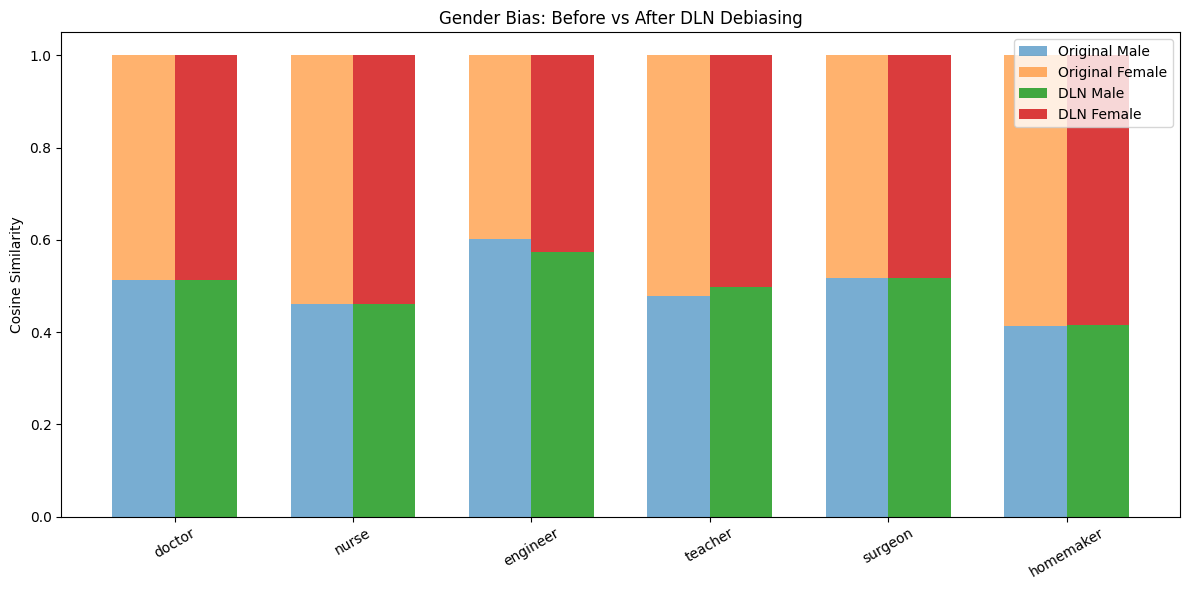

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

original_male_scores, original_female_scores = [], []
debiased_male_scores, debiased_female_scores = [], []
labels = []

for job in occupations:
    if job not in model.wv:
        continue
    labels.append(job)

    orig_vec = model.wv[job]
    sim_male_orig = np.mean([cosine_similarity(orig_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female_orig = np.mean([cosine_similarity(orig_vec, model.wv[f]) for f in female_words if f in model.wv])
    total_orig = sim_male_orig + sim_female_orig
    original_male_scores.append(sim_male_orig / total_orig)
    original_female_scores.append(sim_female_orig / total_orig)
    
    with torch.no_grad():
        vec = torch.tensor(orig_vec, dtype=torch.float32)
        alpha = gate(vec.unsqueeze(0)).item()
        gender_proj = torch.dot(vec, torch.tensor(gender_direction, dtype=torch.float32)) * torch.tensor(gender_direction, dtype=torch.float32)
        debiased_vec = vec - alpha * gender_proj
        job_vec = debiased_vec.numpy()
    print(f"{job:<10} | α = {alpha:.2f}")
    sim_male_deb = np.mean([cosine_similarity(job_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female_deb = np.mean([cosine_similarity(job_vec, model.wv[f]) for f in female_words if f in model.wv])
    total_deb = sim_male_deb + sim_female_deb
    debiased_male_scores.append(sim_male_deb / total_deb)
    debiased_female_scores.append(sim_female_deb / total_deb)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, original_male_scores, width, label='Original Male', alpha=0.6)
plt.bar(x - width/2, original_female_scores, width, bottom=original_male_scores, alpha=0.6)

plt.bar(x + width/2, debiased_male_scores, width, label='DLN Male', alpha=0.9)
plt.bar(x + width/2, debiased_female_scores, width, bottom=debiased_male_scores, alpha=0.9)

plt.xticks(x, labels, rotation=30)
plt.ylabel("Cosine Similarity")
plt.title("Gender Bias: Before vs After DLN Debiasing")
plt.legend(["Original Male", "Original Female", "DLN Male", "DLN Female"])
plt.tight_layout()
plt.show()


##### RCR Approach

###### Approach - 1

In [ ]:
import numpy as np

def normalize(v):
    return v / np.linalg.norm(v)

neutral_anchor_words = ["skill", "expertise", "role", "individual", "talent"]
neutral_vectors = [model.wv[w] for w in neutral_anchor_words if w in model.wv]
P_int = normalize(np.mean(neutral_vectors, axis=0))  

male_words = ["he", "man", "male", "him", "boy"]
female_words = ["she", "woman", "female", "her", "girl"]
male_vec = normalize(np.mean([model.wv[w] for w in male_words if w in model.wv], axis=0))
female_vec = normalize(np.mean([model.wv[w] for w in female_words if w in model.wv], axis=0))
gender_axis = normalize(male_vec - female_vec)

def apply_RCR(word, alpha=0.6, beta=0.3):
    if word not in model.wv:
        return None

    vec = model.wv[word]

    pull_force = alpha * (P_int - vec)

    push_force = beta * (female_vec - male_vec)

    delta = pull_force + push_force

    new_vec = normalize(vec + delta)
    return new_vec

occupation_words = ["doctor", "nurse", "engineer", "teacher", "surgeon", "homemaker"]
for w in occupation_words:
    for _ in range(5): 
        new_vec = apply_RCR(w, alpha=0.6, beta=0.3)
        model.wv[w] = new_vec
    if new_vec is not None:
        model.wv[w] = new_vec


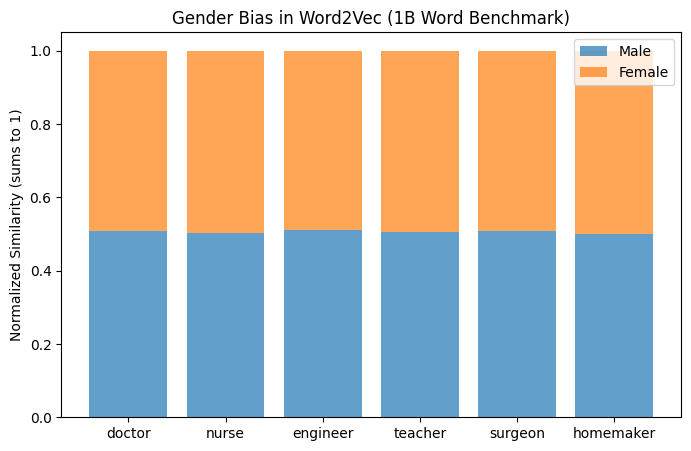

In [23]:
import matplotlib.pyplot as plt

labels, male_scores, female_scores = [], [], []
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
for job in occupation_words:
    if job not in model.wv:
        continue
    job_vec = model.wv[job]
    # print(job_vec)
    sim_male = np.mean([cosine_similarity(job_vec, model.wv[m]) for m in male_words if m in model.wv])
    sim_female = np.mean([cosine_similarity(job_vec, model.wv[f]) for f in female_words if f in model.wv])
    total = sim_male + sim_female
    labels.append(job)
    male_scores.append(sim_male / total)
    female_scores.append(sim_female / total)

x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar(x, male_scores, label="Male", alpha=0.7)
plt.bar(x, female_scores, bottom=male_scores, label="Female", alpha=0.7)
plt.xticks(x, labels)
plt.ylabel("Normalized Similarity (sums to 1)")
plt.title("Gender Bias in Word2Vec (1B Word Benchmark)")
plt.legend()
plt.show()


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

def sim(a, b): return cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0][0]

for w in occupation_words:
    if w in model.wv:
        male_sim = np.mean([sim(model.wv[w], model.wv[m]) for m in male_words if m in model.wv])
        female_sim = np.mean([sim(model.wv[w], model.wv[f]) for f in female_words if f in model.wv])
        print(f"{w:10s} | male_sim={male_sim:.3f} | female_sim={female_sim:.3f}")


doctor     | male_sim=0.137 | female_sim=0.133
nurse      | male_sim=0.136 | female_sim=0.134
engineer   | male_sim=0.126 | female_sim=0.121
teacher    | male_sim=0.135 | female_sim=0.132
surgeon    | male_sim=0.132 | female_sim=0.127
homemaker  | male_sim=0.132 | female_sim=0.132
